In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
df = pd.read_csv("students.csv")

# 1. basic inspection
print("--- First 5 Rows ---")
print(df.head())

print("\n--- Data Types and Shape ---")
print(f"Shape: {df.shape}")
print(df.dtypes)

print("\n--- Summary Statistics ---")
print(df.describe())

# 2. Count passes/fails
print("\n--- Pass/Fail Counts ---")
print(df['passed'].value_counts())

# 3. Average per subject for Pass vs Fail
subject_cols = ['math', 'science', 'english', 'history', 'pe']
pass_avg = df[df['passed'] == 1][subject_cols].mean()
fail_avg = df[df['passed'] == 0][subject_cols].mean()

print("\nAverage Scores for Passing Students:\n", pass_avg)
print("\nAverage Scores for Failing Students:\n", fail_avg)

# 4. Highest overall average student
# We compute a temp column across the row (axis=1)
df['temp_total_avg'] = df[subject_cols].mean(axis=1)
top_student = df.loc[df['temp_total_avg'].idxmax()]
print(f"\nTop Student: {top_student['name']} with {top_student['temp_total_avg']:.2f}")

--- First 5 Rows ---
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

--- Data Types and Shape ---
Shape: (15, 9)
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

--- Summary Statistics ---
            

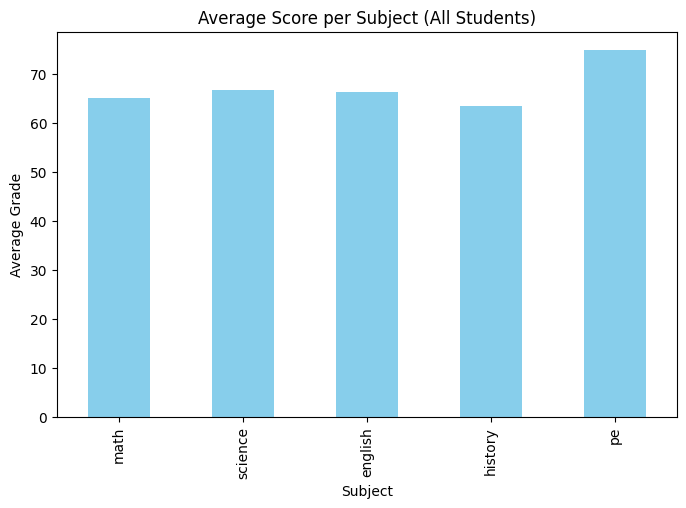

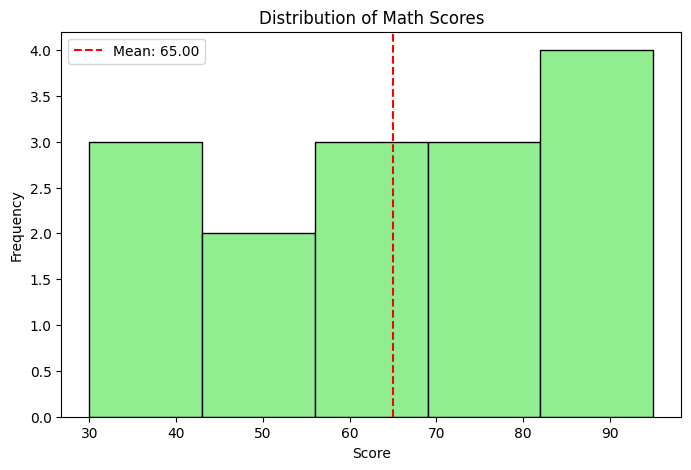

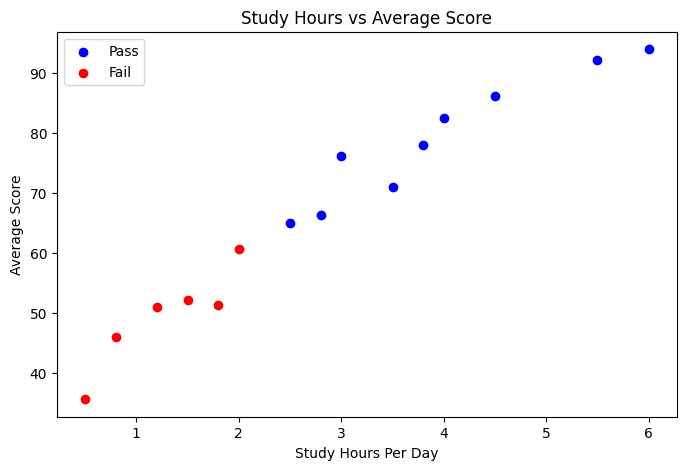

C:\Users\Admin\AppData\Local\Temp\ipykernel_2400\829905945.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attn, fail_attn], labels=['Pass', 'Fail'])


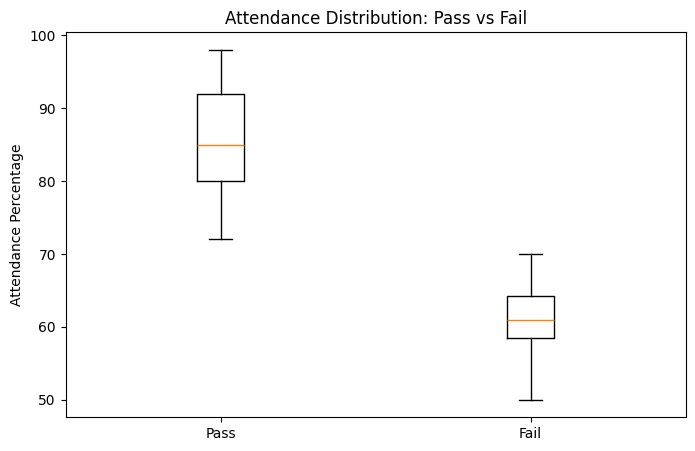

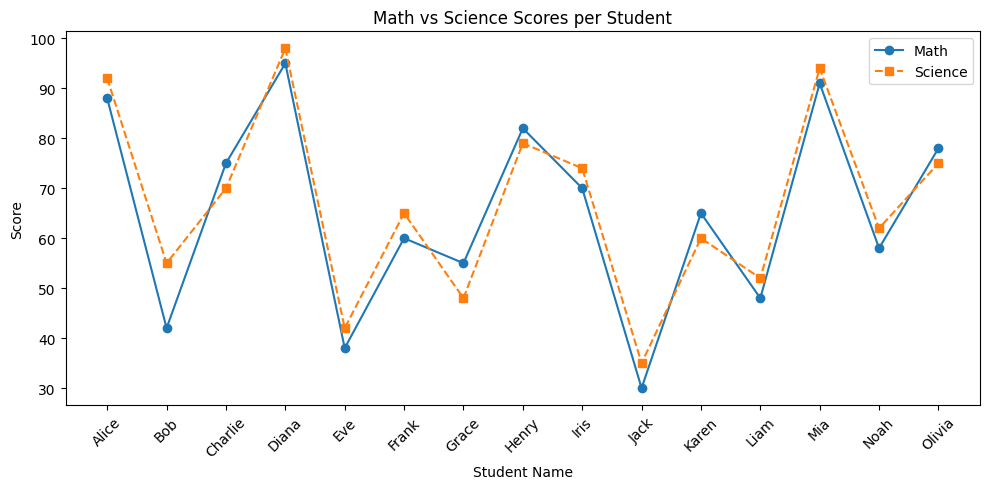

In [13]:
# Prepare the specific avg_score column for the assignment requirement
df['avg_score'] = df[subject_cols].mean(axis=1)

# Plot 1: Bar Chart (Average score per subject)
plt.figure(figsize=(8, 5))
df[subject_cols].mean().plot(kind='bar', color='skyblue')
plt.title("Average Score per Subject (All Students)")
plt.ylabel("Average Grade")
plt.xlabel("Subject")
plt.savefig("plot1_bar.png")
plt.show()

# Plot 2: Histogram (Math scores)
plt.figure(figsize=(8, 5))
plt.hist(df['math'], bins=5, color='lightgreen', edgecolor='black')
plt.axvline(df['math'].mean(), color='red', linestyle='dashed', label=f"Mean: {df['math'].mean():.2f}")
plt.title("Distribution of Math Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("plot2_hist.png")
plt.show()

# Plot 3: Scatter Plot (Study Hours vs Avg Score)
plt.figure(figsize=(8, 5))
passing = df[df['passed'] == 1]
failing = df[df['passed'] == 0]
plt.scatter(passing['study_hours_per_day'], passing['avg_score'], color='blue', label='Pass')
plt.scatter(failing['study_hours_per_day'], failing['avg_score'], color='red', label='Fail')
plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()

# Plot 4: Box Plot (Attendance)
plt.figure(figsize=(8, 5))
pass_attn = df[df['passed'] == 1]['attendance_pct']
fail_attn = df[df['passed'] == 0]['attendance_pct']
plt.boxplot([pass_attn, fail_attn], labels=['Pass', 'Fail'])
plt.title("Attendance Distribution: Pass vs Fail")
plt.ylabel("Attendance Percentage")
plt.savefig("plot4_box.png")
plt.show()

# Plot 5: Line Plot (Math vs Science)
plt.figure(figsize=(10, 5))
plt.plot(df['name'], df['math'], marker='o', label='Math', linestyle='-')
plt.plot(df['name'], df['science'], marker='s', label='Science', linestyle='--')
plt.title("Math vs Science Scores per Student")
plt.xticks(rotation=45)
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.savefig("plot5_line.png")
plt.show()

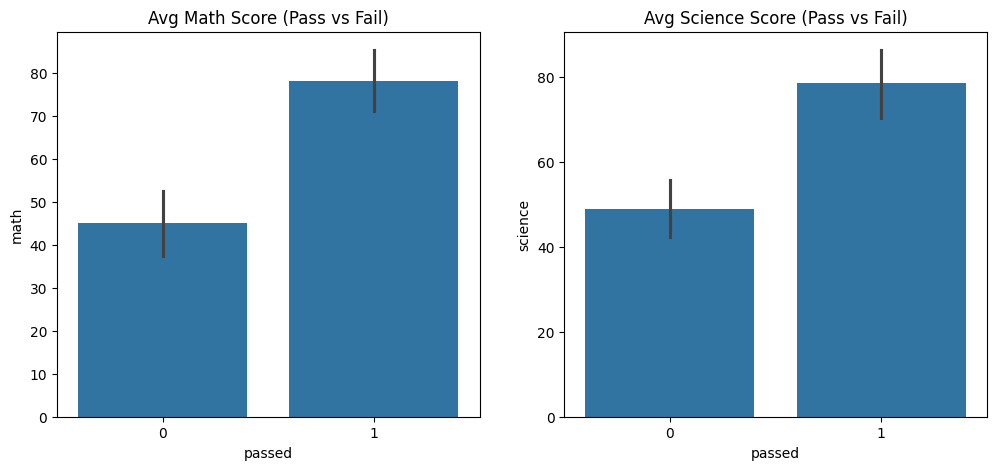

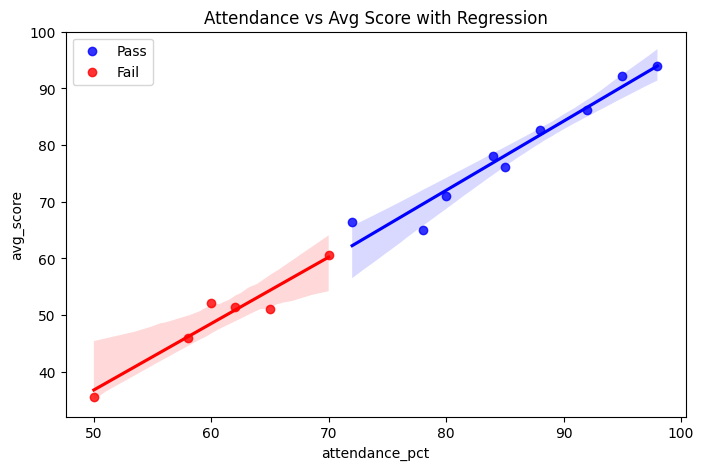

'\nReflection Comment:\nSeaborn was much easier for splitting data by categories (Pass/Fail) using simple parameters, \nwhereas Matplotlib required manual filtering of the DataFrame before plotting. \nHowever, Matplotlib offers more granular control over the specific chart layout and styling.\n'

In [14]:
# 1. Subplots for Math and Science
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Avg Math Score (Pass vs Fail)")
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Avg Science Score (Pass vs Fail)")
plt.savefig("seaborn_bar.png")
plt.show()

# 2. Regression Plot
plt.figure(figsize=(8, 5))
sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score', label='Pass', color='blue')
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score', label='Fail', color='red')
plt.title("Attendance vs Avg Score with Regression")
plt.legend()
plt.savefig("seaborn_scatter_reg.png")
plt.show()

"""
Reflection Comment:
Seaborn was much easier for splitting data by categories (Pass/Fail) using simple parameters, 
whereas Matplotlib required manual filtering of the DataFrame before plotting. 
However, Matplotlib offers more granular control over the specific chart layout and styling.
"""


Training Accuracy: 1.00
Test Accuracy: 1.00

--- Test Set Predictions ---
Jack: Actual=0, Predicted=0 ✅
Liam: Actual=0, Predicted=0 ✅
Alice: Actual=1, Predicted=1 ✅


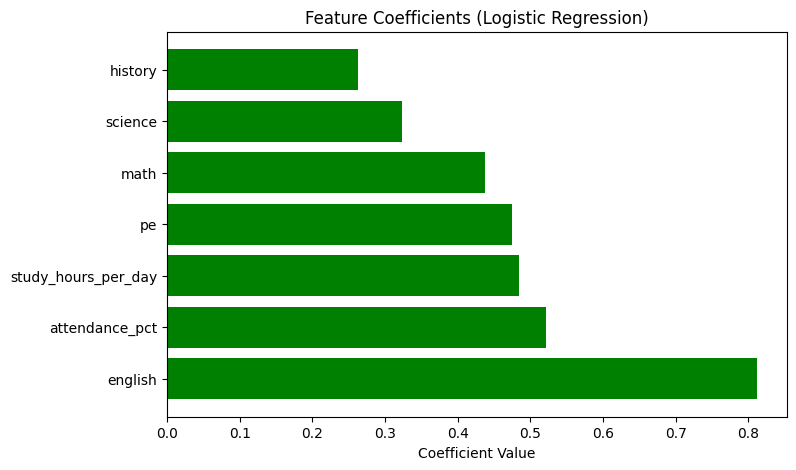


--- New Student Prediction ---
Prediction: Pass
Probability: Fail=0.09, Pass=0.91


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Step 1: Prepare Data
features = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[features]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2: Train
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
print(f"\nTraining Accuracy: {model.score(X_train_scaled, y_train):.2f}")

# Step 3: Evaluate
y_pred = model.predict(X_test_scaled)
print(f"Test Accuracy: {model.score(X_test_scaled, y_test):.2f}")

print("\n--- Test Set Predictions ---")
test_names = df.loc[X_test.index, 'name'].values
for name, actual, pred in zip(test_names, y_test, y_pred):
    status = "✅" if actual == pred else "❌"
    print(f"{name}: Actual={actual}, Predicted={pred} {status}")

# Step 4: Feature Importance
coeffs = model.coef_[0]
feat_importance = pd.DataFrame({'Feature': features, 'Importance': coeffs})
feat_importance['Abs_Importance'] = feat_importance['Importance'].abs()
feat_importance = feat_importance.sort_values(by='Abs_Importance', ascending=False)

plt.figure(figsize=(8, 5))
colors = ['green' if x > 0 else 'red' for x in feat_importance['Importance']]
plt.barh(feat_importance['Feature'], feat_importance['Importance'], color=colors)
plt.title("Feature Coefficients (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.savefig("ml_feature_importance.png")
plt.show()

# Step 5: Bonus - New Student
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]
new_student_scaled = scaler.transform(new_student)
prediction = model.predict(new_student_scaled)
prob = model.predict_proba(new_student_scaled)

print("\n--- New Student Prediction ---")
print(f"Prediction: {'Pass' if prediction[0] == 1 else 'Fail'}")
print(f"Probability: Fail={prob[0][0]:.2f}, Pass={prob[0][1]:.2f}")